|                  |                           |
| ---------------- | ------------------------- |
| **Disciplina**   | Linguagens de Programação |
| **Mês/Ano**      | Setembro de 2026          |
| **Professor(a)** | Alexandre Louzada         |
| **Aluno**        | Enzo Ribas Torres         |

# Trabalho Final - Análise e Visualização de Dados com Python

## Tema 10: Taxa de Desemprego por Faixa Etária e Gênero no Brasil (2015-2023)


## 1. Título e Introdução

**Apresentação do tema.** Este projeto analisa a taxa de desemprego no Brasil entre 2015 e 2023, segmentada por
**faixa etária** (7 faixas, de 15-19 a 60+) e **gênero** (masculino e feminino).

**Contextualização.** O período cobre a recessão de 2015–2016, a recuperação lenta até 2019, o choque da pandemia
em 2020 e a retomada posterior. O desemprego não atinge todos da mesma forma: jovens em busca do primeiro emprego,
mulheres que acumulam trabalho de cuidado e trabalhadores mais velhos com dificuldade de recolocação costumam ser
citados como grupos mais expostos. A média nacional esconde essas diferenças.

**Importância da análise.** Políticas de emprego (qualificação, intermediação de vagas, incentivos à contratação)
têm orçamento limitado. Saber **quais grupos são mais afetados, de forma persistente**, permite direcionar
recursos para onde eles têm mais impacto, em vez de distribuí-los de modo uniforme.


## 2. Definição do Problema

**Pergunta principal:**

> _Quais grupos de faixa etária e gênero são mais vulneráveis ao desemprego no Brasil entre 2015 e 2023, e essa
> vulnerabilidade é persistente ao longo do tempo ou pontual?_

Perguntas de apoio:

1. Como a taxa geral de desemprego evoluiu no período?
2. Existe diferença relevante entre homens e mulheres? Ela muda conforme a idade?
3. Mulheres jovens são mais afetadas que homens adultos (comparação sugerida no enunciado)?

**Por que é relevante?** Um grupo que fica acima da média **em quase todos os anos** tem um problema estrutural
(pede política permanente). Um grupo que só sobe em anos de crise tem um problema conjuntural (pede ação
temporária). Tratar os dois da mesma forma desperdiça recursos.

**Decisão que pode ser tomada:** definir **quais grupos priorizar** em um programa de empregabilidade
(ex.: vagas em cursos de requalificação, subsídio de contratação) e se o programa deve ser permanente ou acionado
apenas em crises.


## 3. Definição de KPIs

**Taxa de desemprego ponderada (%)**

- **Tipo:** Principal
- **Fórmula:** (Total de desempregados / Total da população ativa) x 100
- **Por que foi escolhido:** é a medida oficial de desemprego. Ao agregar grupos, **ponderar pela população ativa**
  evita que um grupo pequeno pese tanto quanto um grande (a média simples das taxas distorce).

**Gap de gênero (p.p.)**

- **Tipo:** Apoio
- **Fórmula:** Taxa feminina - Taxa masculina, na mesma faixa etária
- **Por que foi escolhido:** responde diretamente à comparação homens × mulheres. Positivo = mulheres mais afetadas.

**Persistência (anos acima da média)**

- **Tipo:** Apoio
- **Fórmula:** Nº de anos (de 9) em que a taxa do grupo ficou acima da taxa nacional daquele ano
- **Por que foi escolhido:** separa vulnerabilidade **estrutural** de **pontual**. Um grupo com taxa média alta por
  causa de um único ano ruim não é tão prioritário quanto um que está sempre acima.

**Tendência (p.p./ano)**

- **Tipo:** Apoio
- **Fórmula:** Inclinação da reta de regressão linear (`np.polyfit`) da taxa do grupo ao longo dos anos
- **Por que foi escolhido:** indica se a situação do grupo está piorando ou melhorando.


## 4. Aquisição dos Dados

- **Fonte:** arquivo `Simulacao_Desemprego_FaixaEtaria_Genero_2015_2023.xlsx`, fornecido pelo professor para o
  Tema 10. Como o nome indica, trata-se de uma **base simulada**, inspirada na estrutura da PNAD Contínua (IBGE).
- **Método de obtenção:** **upload** do arquivo no Google Colab (a célula abaixo abre o seletor de arquivos quando
  executada no Colab; fora dele, lê o arquivo da pasta local).

**Variáveis principais (colunas originais):**

| Coluna                    | Tipo    | Descrição                                                    |
| ------------------------- | ------- | ------------------------------------------------------------ |
| `Ano`                     | inteiro | Ano de referência (2015 a 2023)                              |
| `Faixa Etária`            | texto   | 15-19, 20-24, 25-29, 30-39, 40-49, 50-59, 60+                |
| `Gênero`                  | texto   | Masculino / Feminino                                         |
| `População Ativa`         | inteiro | Pessoas na força de trabalho (ocupadas + procurando emprego) |
| `Taxa de Desemprego (%)`  | decimal | Percentual da população ativa sem emprego                    |
| `Desempregados Estimados` | inteiro | População Ativa x Taxa                                       |


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pd.set_option('display.float_format', '{:.2f}'.format)

COR_MASC = '#2a78d6'
COR_FEM = "#e9319c"
COR_GERAL = '#52514e'
CORES_GENERO = {'Masculino': COR_MASC, 'Feminino': COR_FEM}


def pct(valor, casas=1):
    return f'{valor:.{casas}f}%'.replace('.', ',')


EIXO_PCT = mtick.FuncFormatter(lambda v, _: pct(v, 0))

sns.set_theme(style='white', font_scale=1.0)
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.titlelocation': 'left',
})

In [4]:
ARQUIVO = 'Simulacao_Desemprego_FaixaEtaria_Genero_2015_2023.xlsx'

df_bruto = pd.read_excel(ARQUIVO)
print(f'{df_bruto.shape[0]} linhas x {df_bruto.shape[1]} colunas')
df_bruto.head(10)

126 linhas x 6 colunas


,Ano,Faixa Etária,Gênero,População Ativa,Taxa de Desemprego (%),Desempregados Estimados
0,2015,15-19,Masculino,231932,10.70,24816
1,2015,15-19,Feminino,744167,7.30,54324
2,2015,20-24,Masculino,154886,14.80,22923
3,2015,20-24,Feminino,621430,12.00,74571
4,2015,25-29,Masculino,999159,5.00,49957
5,2015,25-29,Feminino,291335,10.00,29133
6,2015,30-39,Masculino,429365,16.70,71703
7,2015,30-39,Feminino,421879,5.00,21093
8,2015,40-49,Masculino,876997,19.00,166629
9,2015,40-49,Feminino,203355,4.00,8134


In [5]:
df_bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Ano                      126 non-null    int64  
 1   Faixa Etária             126 non-null    str    
 2   Gênero                   126 non-null    str    
 3   População Ativa          126 non-null    int64  
 4   Taxa de Desemprego (%)   126 non-null    float64
 5   Desempregados Estimados  126 non-null    int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 7.7 KB


## 5. Limpeza e Preparação dos Dados

Etapas:

1. **Renomear colunas** para nomes curtos, sem acento e sem espaço (mais seguros para código).
2. **Verificar valores nulos e duplicados** (cada combinação ano × faixa × gênero deve aparecer uma única vez).
3. **Converter tipos:** `faixa_etaria` vira categoria **ordenada** (para os gráficos seguirem a ordem da idade, e
   não a ordem alfabética) e `genero` vira categoria.
4. **Validar consistência:** conferir se `desempregados ≈ populacao_ativa × taxa`.
5. **Criar novas variáveis:** `grupo` (rótulo gênero + faixa), `ciclo_vida` (Jovem / Adulto / 50+) e a
   comparação de cada grupo com a taxa nacional do ano.


In [6]:
df = df_bruto.rename(columns={
    'Ano': 'ano',
    'Faixa Etária': 'faixa_etaria',
    'Gênero': 'genero',
    'População Ativa': 'populacao_ativa',
    'Taxa de Desemprego (%)': 'taxa_desemprego',
    'Desempregados Estimados': 'desempregados',
})

print('Valores nulos por coluna:')
print(df.isna().sum(), end='\n\n')
print('Linhas duplicadas (ano, faixa, gênero):', df.duplicated(['ano', 'faixa_etaria', 'genero']).sum())
print('Anos:', sorted(df['ano'].unique()))
print('Faixas:', df['faixa_etaria'].unique().tolist())
print('Gêneros:', df['genero'].unique().tolist())

Valores nulos por coluna:
ano                0
faixa_etaria       0
genero             0
populacao_ativa    0
taxa_desemprego    0
desempregados      0
dtype: int64

Linhas duplicadas (ano, faixa, gênero): 0
Anos: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Faixas: ['15-19', '20-24', '25-29', '30-39', '40-49', '50-59', '60+']
Gêneros: ['Masculino', 'Feminino']


Não há valores nulos nem duplicados, e a base está completa: 9 anos × 7 faixas × 2 gêneros = 126 linhas.
Mesmo assim, o tratamento de nulos fica explícito no código abaixo, para que o notebook continue funcionando
caso uma versão futura da base venha com falhas (ex.: recalcular `desempregados` a partir da taxa).


In [7]:
ORDEM_FAIXAS = ['15-19', '20-24', '25-29', '30-39', '40-49', '50-59', '60+']

df['faixa_etaria'] = df['faixa_etaria'].str.strip()
df['genero'] = df['genero'].str.strip().str.title()

faltando = df['desempregados'].isna()
df.loc[faltando, 'desempregados'] = (df['populacao_ativa'] * df['taxa_desemprego'] / 100).round()
df = df.dropna(subset=['taxa_desemprego', 'populacao_ativa'])

df['ano'] = df['ano'].astype(int)
df['populacao_ativa'] = df['populacao_ativa'].astype(int)
df['desempregados'] = df['desempregados'].astype(int)
df['taxa_desemprego'] = df['taxa_desemprego'].astype(float)
df['faixa_etaria'] = pd.Categorical(df['faixa_etaria'], categories=ORDEM_FAIXAS, ordered=True)
df['genero'] = pd.Categorical(df['genero'], categories=['Masculino', 'Feminino'])

diferenca = df['desempregados'] - df['populacao_ativa'] * df['taxa_desemprego'] / 100
print(f'Maior diferença absoluta entre desempregados informados e calculados: {diferenca.abs().max():.2f} pessoa')

Maior diferença absoluta entre desempregados informados e calculados: 1.00 pessoa


A diferença máxima é menor que 1 pessoa (apenas arredondamento), então a coluna `desempregados` é consistente e
pode ser usada para calcular a **taxa ponderada** (KPI principal).


In [8]:
df['grupo'] = df['genero'].astype(str).str[0] + ' ' + df['faixa_etaria'].astype(str)

CICLO_VIDA = {'15-19': 'Jovem (15-24)', '20-24': 'Jovem (15-24)',
              '25-29': 'Adulto (25-49)', '30-39': 'Adulto (25-49)', '40-49': 'Adulto (25-49)',
              '50-59': '50+', '60+': '50+'}
df['ciclo_vida'] = pd.Categorical(df['faixa_etaria'].astype(str).map(CICLO_VIDA),
                                  categories=['Jovem (15-24)', 'Adulto (25-49)', '50+'], ordered=True)


def taxa_ponderada(dados, por):
    agg = dados.groupby(por, observed=True)[['desempregados', 'populacao_ativa']].sum()
    agg['taxa'] = agg['desempregados'] / agg['populacao_ativa'] * 100
    return agg


taxa_nacional = taxa_ponderada(df, 'ano')['taxa'].rename('taxa_nacional_ano')
df = df.merge(taxa_nacional, on='ano')
df['dif_vs_nacional'] = df['taxa_desemprego'] - df['taxa_nacional_ano']
df['acima_nacional'] = df['dif_vs_nacional'] > 0

df.head()

,ano,faixa_etaria,genero,populacao_ativa,taxa_desemprego,desempregados,grupo,ciclo_vida,taxa_nacional_ano,dif_vs_nacional,acima_nacional
0,2015,15-19,Masculino,231932,10.70,24816,M 15-19,Jovem (15-24),10.40,0.30,True
1,2015,15-19,Feminino,744167,7.30,54324,F 15-19,Jovem (15-24),10.40,-3.10,False
2,2015,20-24,Masculino,154886,14.80,22923,M 20-24,Jovem (15-24),10.40,4.40,True
3,2015,20-24,Feminino,621430,12.00,74571,F 20-24,Jovem (15-24),10.40,1.60,True
4,2015,25-29,Masculino,999159,5.00,49957,M 25-29,Adulto (25-49),10.40,-5.40,False


## 6. Análise Exploratória

### 6.1 Estatísticas descritivas


In [9]:
df[['populacao_ativa', 'taxa_desemprego', 'desempregados']].describe().T

,count,mean,std,min,25%,50%,75%,max
populacao_ativa,126.00,533478.10,268526.58,115708.00,270312.00,558162.00,744989.00,999684.00
taxa_desemprego,126.00,13.02,5.44,4.00,8.33,12.95,17.85,21.80
desempregados,126.00,68441.63,44917.28,8134.00,34207.75,57714.50,94754.25,201995.00


In [10]:
df.groupby('genero', observed=True)['taxa_desemprego'].describe()

,count,mean,std,min,25%,50%,75%,max
genero,,,,,,,,
Masculino,63.00,12.85,5.48,4.40,8.35,12.40,18.20,21.70
Feminino,63.00,13.20,5.44,4.00,8.25,13.60,17.75,21.80


As taxas variam de 4% a quase 22%, com desvio-padrão de ~5,4 p.p. — uma dispersão grande. As estatísticas por
gênero são quase idênticas (médias de 12,8% e 13,2%), o que já sugere que **o gênero, sozinho, não explica muito
do desemprego nesta base**. É preciso cruzar com a faixa etária.

### 6.2 Evolução da taxa nacional (KPI principal por ano)


In [11]:
evolucao = taxa_ponderada(df, 'ano')
evolucao['variacao_pp'] = evolucao['taxa'].diff()
evolucao

,desempregados,populacao_ativa,taxa,variacao_pp
ano,,,,
2015,697000,6702946,10.40,NaN
2016,872605,7861079,11.10,0.70
2017,1003718,8151886,12.31,1.21
2018,916312,7411684,12.36,0.05
2019,1103641,7840898,14.08,1.71
2020,1050393,7034378,14.93,0.86
2021,787873,7273179,10.83,-4.10
2022,976448,5979246,16.33,5.50
2023,1215656,8962945,13.56,-2.77


In [12]:
taxa_geral = df['desempregados'].sum() / df['populacao_ativa'].sum() * 100
print(f'Taxa ponderada do período inteiro: {taxa_geral:.2f}%')
print(f"2015 -> 2023: {evolucao.loc[2015, 'taxa']:.2f}% -> {evolucao.loc[2023, 'taxa']:.2f}% "
      f"({evolucao.loc[2023, 'taxa'] - evolucao.loc[2015, 'taxa']:+.2f} p.p.)")
print(f"Pico: {evolucao['taxa'].idxmax()} ({evolucao['taxa'].max():.2f}%)")

Taxa ponderada do período inteiro: 12.83%
2015 -> 2023: 10.40% -> 13.56% (+3.16 p.p.)
Pico: 2022 (16.33%)


### 6.3 Comparação entre gêneros e faixas etárias


In [13]:
por_genero = taxa_ponderada(df, 'genero')
print(por_genero, end='\n\n')
print(f"Gap de gênero no período: {por_genero.loc['Feminino', 'taxa'] - por_genero.loc['Masculino', 'taxa']:+.2f} p.p.")

           desempregados  populacao_ativa  taxa
genero                                         
Masculino        4387244         34729799 12.63
Feminino         4236402         32488442 13.04

Gap de gênero no período: +0.41 p.p.


In [14]:
faixa_genero = taxa_ponderada(df, ['faixa_etaria', 'genero'])['taxa'].unstack()
faixa_genero['gap_pp'] = faixa_genero['Feminino'] - faixa_genero['Masculino']
faixa_genero.sort_values('gap_pp', ascending=False)

genero,Masculino,Feminino,gap_pp
faixa_etaria,,,
40-49,12.88,17.03,4.15
15-19,11.54,14.62,3.07
50-59,10.88,12.64,1.76
60+,12.55,12.66,0.11
25-29,11.98,11.91,-0.07
30-39,14.69,12.48,-2.20
20-24,13.87,11.29,-2.58


O gap de gênero **médio** é pequeno (+0,4 p.p.), mas ele esconde diferenças grandes e de sinais opostos dentro das
faixas: mulheres de **40–49** (+4,1 p.p.) e de **15–19** (+3,1 p.p.) estão bem pior que os homens da mesma idade,
enquanto na faixa de **20–24** e **30–39** são os homens os mais afetados (−2,6 e −2,2 p.p.). As diferenças se
anulam na média — por isso a análise precisa ser feita no nível **gênero × faixa**.

### 6.4 Ranking de vulnerabilidade dos 14 grupos


In [15]:
def tendencia(serie_anos, serie_taxa):
    return np.polyfit(serie_anos, serie_taxa, deg=1)[0]


ranking = (
    df.groupby('grupo')
      .agg(genero=('genero', 'first'),
           faixa=('faixa_etaria', 'first'),
           desempregados=('desempregados', 'sum'),
           populacao_ativa=('populacao_ativa', 'sum'),
           anos_acima_media=('acima_nacional', 'sum'),
           volatilidade_pp=('taxa_desemprego', 'std'))
)
ranking['taxa_ponderada'] = ranking['desempregados'] / ranking['populacao_ativa'] * 100
ranking['dif_vs_nacional_pp'] = ranking['taxa_ponderada'] - taxa_geral
ranking['participacao_desempregados_%'] = ranking['desempregados'] / ranking['desempregados'].sum() * 100
ranking['tendencia_pp_ano'] = [tendencia(g['ano'], g['taxa_desemprego']) for _, g in df.groupby('grupo')]
ranking = ranking.sort_values('taxa_ponderada', ascending=False)

ranking[['taxa_ponderada', 'dif_vs_nacional_pp', 'anos_acima_media', 'tendencia_pp_ano',
         'volatilidade_pp', 'participacao_desempregados_%']]

,taxa_ponderada,dif_vs_nacional_pp,anos_acima_media,tendencia_pp_ano,volatilidade_pp,participacao_desempregados_%
grupo,,,,,,
F 40-49,17.03,4.20,6,1.55,7.03,7.73
M 30-39,14.69,1.86,8,0.29,4.75,7.04
F 15-19,14.62,1.79,4,0.43,5.95,5.69
M 20-24,13.87,1.04,6,0.43,4.40,8.57
M 40-49,12.88,0.05,4,-1.54,5.42,8.23
F 60+,12.66,-0.17,6,1.33,5.22,8.70
F 50-59,12.64,-0.19,6,-0.47,4.25,6.82
M 60+,12.55,-0.28,3,0.41,5.04,9.00
F 30-39,12.48,-0.34,4,0.65,6.78,7.88


Combinando os KPIs, três grupos se destacam:

- **Mulheres 40–49:** maior taxa do período (17,0%, **+4,2 p.p.** acima da média nacional), acima da média em 6 dos
  9 anos e com a **pior tendência** (+1,6 p.p. por ano) — o problema está crescendo.
- **Homens 30–39:** segunda maior taxa (14,7%) e o grupo **mais persistente**: acima da média nacional em **8 dos
  9 anos**. É o caso mais claro de vulnerabilidade estrutural.
- **Mulheres 15–19:** terceira maior taxa (14,6%), mas acima da média em apenas 4 anos — sua média é puxada por
  anos específicos muito ruins (vulnerabilidade mais **pontual**).

No outro extremo, **homens 50–59** têm a menor taxa (10,9%) e ficaram acima da média em apenas 2 anos.

### 6.5 Comparação pedida no enunciado: mulheres jovens × homens adultos


In [16]:
jovens_f = df[(df['ciclo_vida'] == 'Jovem (15-24)') & (df['genero'] == 'Feminino')]
adultos_m = df[(df['ciclo_vida'] == 'Adulto (25-49)') & (df['genero'] == 'Masculino')]

comparacao = pd.DataFrame({
    'Mulheres jovens (15-24)': taxa_ponderada(jovens_f, 'ano')['taxa'],
    'Homens adultos (25-49)': taxa_ponderada(adultos_m, 'ano')['taxa'],
})
comparacao['diferenca_pp'] = comparacao.iloc[:, 0] - comparacao.iloc[:, 1]
print(comparacao, end='\n\n')

tf = jovens_f['desempregados'].sum() / jovens_f['populacao_ativa'].sum() * 100
tm = adultos_m['desempregados'].sum() / adultos_m['populacao_ativa'].sum() * 100
print(f'Período inteiro -> mulheres jovens: {tf:.2f}% | homens adultos: {tm:.2f}%')
print(f"Anos em que mulheres jovens estiveram pior: {(comparacao['diferenca_pp'] > 0).sum()} de 9")

      Mulheres jovens (15-24)  Homens adultos (25-49)  diferenca_pp
ano                                                                
2015                     9.44                   12.50         -3.07
2016                    12.76                   13.13         -0.37
2017                    16.24                   17.78         -1.54
2018                    12.64                   14.51         -1.88
2019                    18.86                    6.20         12.66
2020                     8.77                   15.59         -6.82
2021                    10.67                   10.05          0.62
2022                    10.06                   12.00         -1.94
2023                    12.94                   15.63         -2.69

Período inteiro -> mulheres jovens: 12.57% | homens adultos: 13.14%
Anos em que mulheres jovens estiveram pior: 2 de 9


**Resultado contraintuitivo:** nesta base, mulheres jovens **não** têm desemprego maior que homens adultos no
agregado (12,6% × 13,1%) e ficam pior em só 2 dos 9 anos (em 2019, com uma diferença isolada de +12,7 p.p.). Isso é diferente do que a PNAD real mostra (onde jovens, sobretudo mulheres, têm taxas bem acima dos
adultos) e é um ponto de atenção sobre a base, discutido nas limitações.

### 6.6 A diferença entre gêneros é real ou pode ser acaso?

Para não tirar conclusões de diferenças pequenas, aplicamos um **teste de permutação** (feito com NumPy):
embaralhamos os rótulos de gênero 10.000 vezes e verificamos com que frequência uma diferença de médias
igual ou maior que a observada aparece por puro acaso.


In [17]:
def teste_permutacao(a, b, n=10_000, seed=42):
    rng = np.random.default_rng(seed)
    observado = a.mean() - b.mean()
    juntos = np.concatenate([a, b])
    difs = np.empty(n)
    for i in range(n):
        rng.shuffle(juntos)
        difs[i] = juntos[:len(a)].mean() - juntos[len(a):].mean()
    return observado, (np.abs(difs) >= abs(observado)).mean()


fem = df.loc[df['genero'] == 'Feminino', 'taxa_desemprego'].to_numpy()
masc = df.loc[df['genero'] == 'Masculino', 'taxa_desemprego'].to_numpy()
dif, p = teste_permutacao(fem, masc)
print(f'Feminino - Masculino (todas as faixas): {dif:+.2f} p.p. | p-valor = {p:.3f}')

f4049 = df.query("grupo == 'F 40-49'")['taxa_desemprego'].to_numpy()
m4049 = df.query("grupo == 'M 40-49'")['taxa_desemprego'].to_numpy()
dif, p = teste_permutacao(f4049, m4049)
print(f'Mulheres x Homens 40-49:                {dif:+.2f} p.p. | p-valor = {p:.3f}')

Feminino - Masculino (todas as faixas): +0.35 p.p. | p-valor = 0.719
Mulheres x Homens 40-49:                +2.84 p.p. | p-valor = 0.342


Com p-valores bem acima de 0,05, **nem o gap geral nem o gap da faixa 40–49 são estatisticamente
significativos**: com apenas 9 anos e taxas que oscilam muito, diferenças de 1 a 4 p.p. podem surgir por acaso.
Isso não invalida o ranking, mas obriga a tratar as conclusões como **indícios**, não como prova.


## 7. Visualizações

Cada gráfico responde a uma parte da pergunta. Cores fixas em todo o notebook: **azul = homens**,
**laranja = mulheres**, **cinza = total nacional**.

### 7.1 Como o desemprego evoluiu? (linhas)


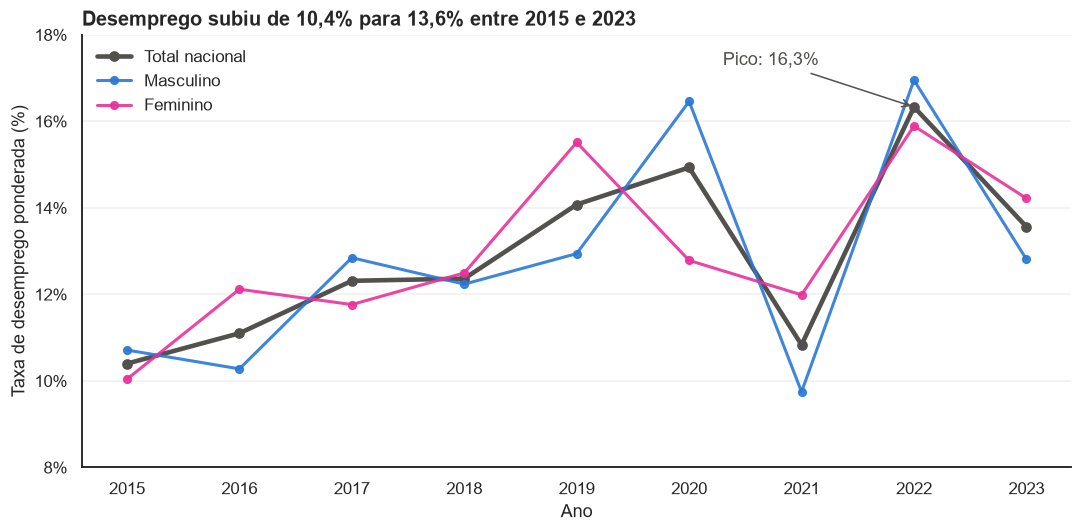

In [18]:
evol_genero = taxa_ponderada(df, ['ano', 'genero'])['taxa'].unstack()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(evolucao.index, evolucao['taxa'], color=COR_GERAL, lw=3, marker='o', label='Total nacional')
for genero, cor in CORES_GENERO.items():
    ax.plot(evol_genero.index, evol_genero[genero], color=cor, lw=2, marker='o', ms=5, alpha=0.9, label=genero)

ax.annotate(f"Pico: {pct(evolucao['taxa'].max())}", xy=(2022, evolucao.loc[2022, 'taxa']),
            xytext=(2020.3, 17.3), arrowprops=dict(arrowstyle='->', color=COR_GERAL), color=COR_GERAL)
ax.set_title('Desemprego subiu de 10,4% para 13,6% entre 2015 e 2023')
ax.set_xlabel('Ano')
ax.set_ylabel('Taxa de desemprego ponderada (%)')
ax.yaxis.set_major_formatter(EIXO_PCT)
ax.set_ylim(8, 18)
ax.set_xticks(evolucao.index)
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

**Leitura:** a tendência geral é de **alta** (+3,2 p.p. no período), com picos em 2020 (pandemia) e 2022. As linhas
de homens e mulheres se cruzam várias vezes — em 2020 os homens foram mais atingidos, em 2019 as mulheres. Não há
um gênero sistematicamente pior.

### 7.2 Quais grupos são mais afetados? (barras — ranking)


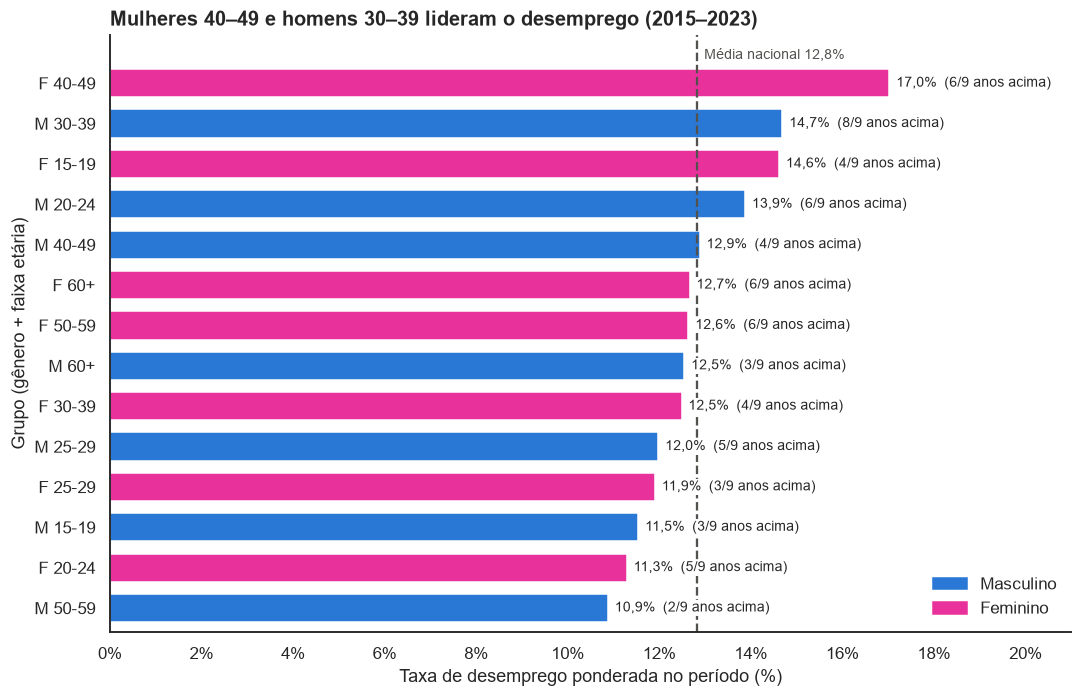

In [19]:
dados = ranking.sort_values('taxa_ponderada')
cores = dados['genero'].map(CORES_GENERO)

fig, ax = plt.subplots(figsize=(10, 6.5))
barras = ax.barh(dados.index, dados['taxa_ponderada'], color=cores, height=0.7)
ax.axvline(taxa_geral, color=COR_GERAL, ls='--', lw=1.5)
ax.text(taxa_geral + 0.15, len(dados) - 0.4, f'Média nacional {pct(taxa_geral)}', color=COR_GERAL, fontsize=9)

for barra, (_, linha) in zip(barras, dados.iterrows()):
    ax.text(barra.get_width() + 0.15, barra.get_y() + barra.get_height() / 2,
            f"{pct(linha['taxa_ponderada'])}  ({int(linha['anos_acima_media'])}/9 anos acima)",
            va='center', fontsize=9, bbox=dict(facecolor='white', edgecolor='none', pad=1))

ax.set_title('Mulheres 40–49 e homens 30–39 lideram o desemprego (2015–2023)')
ax.set_xlabel('Taxa de desemprego ponderada no período (%)')
ax.set_ylabel('Grupo (gênero + faixa etária)')
ax.set_xlim(0, 21)
ax.set_ylim(-0.6, len(dados) + 0.2)
ax.xaxis.set_major_locator(mtick.MultipleLocator(2))
ax.xaxis.set_major_formatter(EIXO_PCT)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in CORES_GENERO.values()],
          labels=list(CORES_GENERO), frameon=False, loc='lower right')
plt.tight_layout()
plt.show()

**Leitura:** o gráfico responde diretamente à pergunta principal. Os três grupos do topo ficam 2 a 4 p.p. acima da
média. O rótulo de persistência mostra que **homens 30–39 (8/9 anos)** é o grupo mais _consistentemente_ afetado,
enquanto **mulheres 15–19 (4/9)** tem média alta, mas menos regularidade.

### 7.3 Homens e mulheres na mesma idade (barras agrupadas + gap)


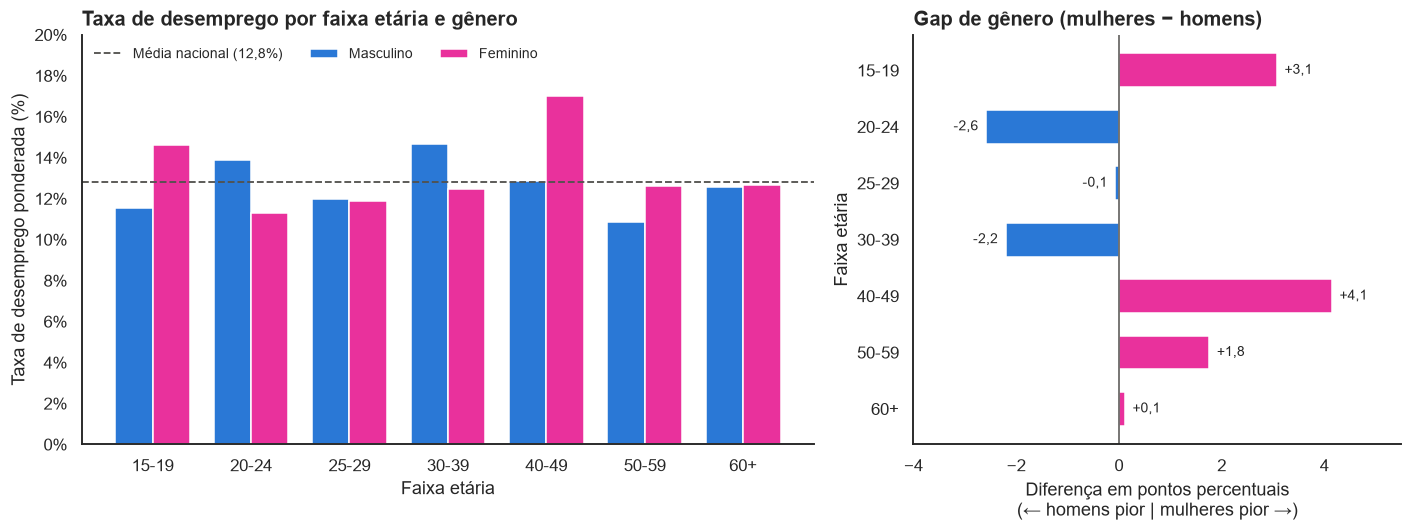

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [3, 2]})

x = np.arange(len(ORDEM_FAIXAS))
larg = 0.38
for i, (genero, cor) in enumerate(CORES_GENERO.items()):
    ax1.bar(x + (i - 0.5) * larg, faixa_genero[genero], width=larg, color=cor, label=genero)
ax1.axhline(taxa_geral, color=COR_GERAL, ls='--', lw=1.2, label=f'Média nacional ({pct(taxa_geral)})')
ax1.set_xticks(x, ORDEM_FAIXAS)
ax1.set_title('Taxa de desemprego por faixa etária e gênero')
ax1.set_xlabel('Faixa etária')
ax1.set_ylabel('Taxa de desemprego ponderada (%)')
ax1.yaxis.set_major_locator(mtick.MultipleLocator(2))
ax1.yaxis.set_major_formatter(EIXO_PCT)
ax1.set_ylim(0, 20)
ax1.legend(frameon=False, ncols=3, loc='upper left', fontsize=9)

gap = faixa_genero['gap_pp']
ax2.barh(ORDEM_FAIXAS, gap, color=np.where(gap > 0, COR_FEM, COR_MASC), height=0.6)
ax2.axvline(0, color=COR_GERAL, lw=1)
for i, v in enumerate(gap):
    ax2.text(v + (0.15 if v > 0 else -0.15), i, f'{v:+.1f}'.replace('.', ','), va='center', ha='left' if v > 0 else 'right', fontsize=9)
ax2.invert_yaxis()
ax2.set_xlim(-4, 5.5)
ax2.set_title('Gap de gênero (mulheres − homens)')
ax2.set_xlabel('Diferença em pontos percentuais\n(← homens pior | mulheres pior →)')
ax2.set_ylabel('Faixa etária')

plt.tight_layout()
plt.show()

**Leitura:** o gap muda de sinal conforme a idade. Mulheres estão pior no **início** (15–19) e na **meia-idade**
(40–59); homens estão pior entre **20–24** e **30–39**. Uma política "para mulheres" ou "para homens" genérica
erraria o alvo: o recorte precisa ser por **gênero e idade ao mesmo tempo**.

### 7.4 A vulnerabilidade é persistente? (heatmap)


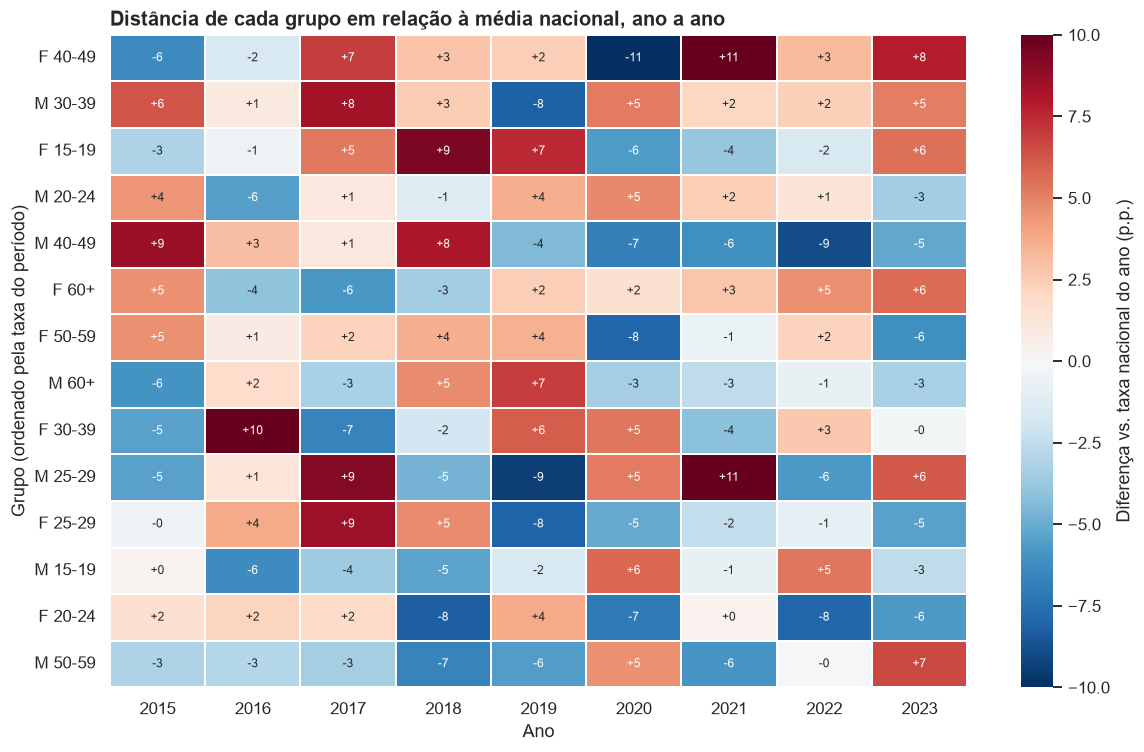

In [21]:
mapa = df.pivot_table(index='grupo', columns='ano', values='dif_vs_nacional', observed=True)
mapa = mapa.loc[ranking.index]

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(mapa, cmap='RdBu_r', center=0, vmin=-10, vmax=10, annot=True, fmt='+.0f',
            annot_kws={'size': 8}, linewidths=1, linecolor='white',
            cbar_kws={'label': 'Diferença vs. taxa nacional do ano (p.p.)'}, ax=ax)
ax.set_title('Distância de cada grupo em relação à média nacional, ano a ano')
ax.set_xlabel('Ano')
ax.set_ylabel('Grupo (ordenado pela taxa do período)')
plt.tight_layout()
plt.show()

**Leitura:** vermelho = pior que a média do ano; azul = melhor. A linha de **M 30–39** é quase toda vermelha
(só 2019 fica abaixo), confirmando a persistência. **F 40–49** tem os extremos mais fortes (−11 p.p. em 2020 e
+11 p.p. em 2021), mas fica vermelha em 6 dos 9 anos e em **todos os anos de 2021 a 2023**, coerente com a
tendência de piora. Nos demais grupos o padrão é um "xadrez" de vermelhos e
azuis: nenhum grupo está sempre protegido, o que revela **alta instabilidade** das taxas.

### 7.5 Tendência do grupo mais afetado (linhas)


Reta de tendência F 40-49: 8.3% (2015) -> 20.8% (2023)


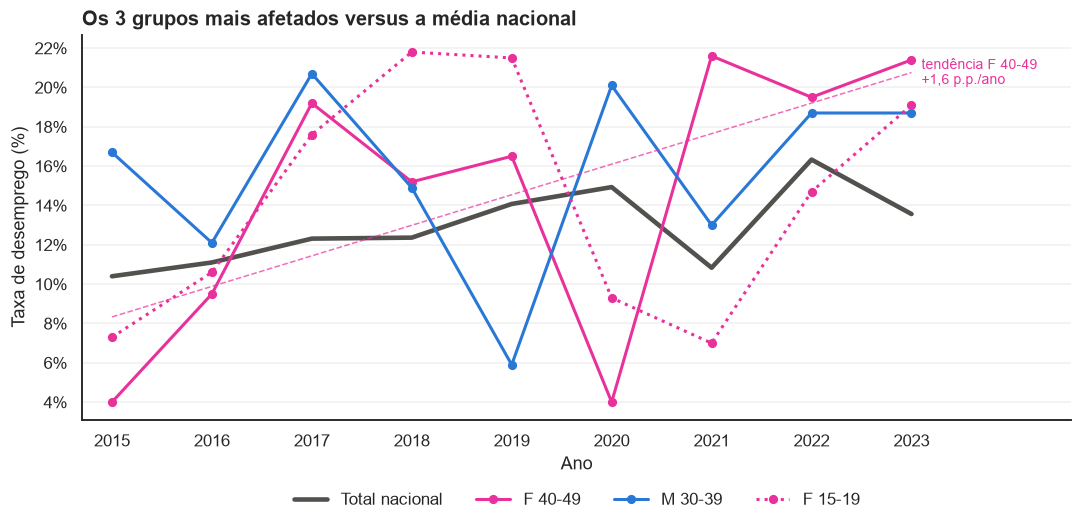

In [22]:
destaques = ['F 40-49', 'M 30-39', 'F 15-19']
estilos = {'F 40-49': (COR_FEM, '-'), 'M 30-39': (COR_MASC, '-'), 'F 15-19': (COR_FEM, ':')}

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(evolucao.index, evolucao['taxa'], color=COR_GERAL, lw=3, label='Total nacional')
for g in destaques:
    serie = df[df['grupo'] == g].set_index('ano')['taxa_desemprego']
    cor, ls = estilos[g]
    ax.plot(serie.index, serie, color=cor, ls=ls, lw=2, marker='o', ms=5, label=g)

serie = df[df['grupo'] == 'F 40-49'].set_index('ano')['taxa_desemprego']
coef = np.polyfit(serie.index, serie, 1)
ax.plot(serie.index, np.polyval(coef, serie.index), color=COR_FEM, lw=1, ls='--', alpha=0.7)
ax.text(2023.1, np.polyval(coef, 2023), 'tendência F 40-49\n' + f'{coef[0]:+.1f}'.replace('.', ',') + ' p.p./ano', color=COR_FEM, fontsize=9, va='center')

ax.set_title('Os 3 grupos mais afetados versus a média nacional')
ax.set_xlabel('Ano')
ax.set_ylabel('Taxa de desemprego (%)')
ax.yaxis.set_major_locator(mtick.MultipleLocator(2))
ax.yaxis.set_major_formatter(EIXO_PCT)
ax.set_xticks(evolucao.index)
ax.set_xlim(2014.7, 2024.6)
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncols=4)
print(f'Reta de tendência F 40-49: {np.polyval(coef, 2015):.1f}% (2015) -> {np.polyval(coef, 2023):.1f}% (2023)')
plt.tight_layout()
plt.show()

**Leitura:** as séries individuais oscilam muito mais que a média nacional (saltos de 10 p.p. de um ano para
outro), mas a reta de tendência de **mulheres 40–49** sobe claramente: de ~8% em 2015 para ~21% em 2023, pela
reta ajustada. É o grupo cuja situação mais se deteriorou.

### 7.6 Como as taxas se distribuem? (histograma)


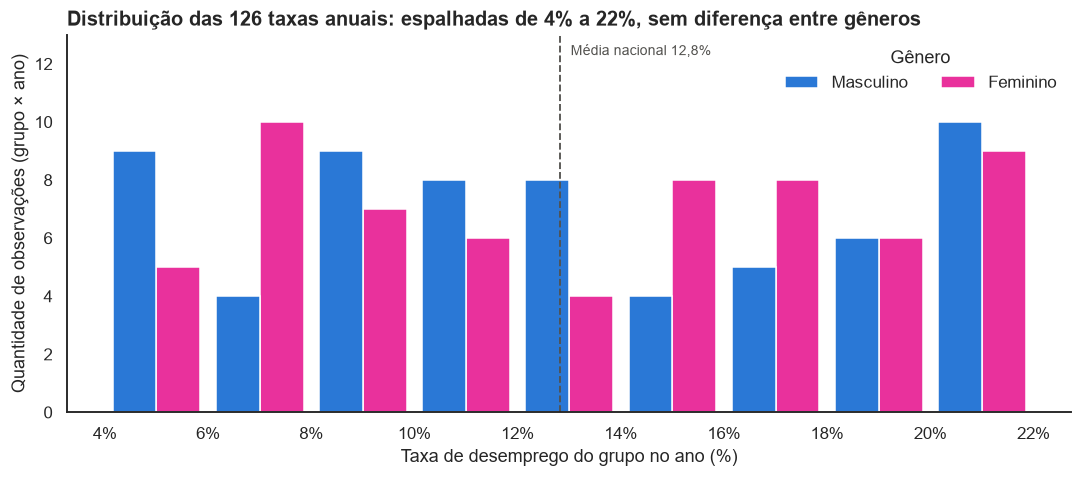

In [23]:
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.histplot(data=df, x='taxa_desemprego', hue='genero', palette=CORES_GENERO, bins=np.arange(4, 24, 2),
             multiple='dodge', shrink=0.85, edgecolor='white', alpha=1, ax=ax)
ax.set_ylim(0, 13)
ax.xaxis.set_major_locator(mtick.MultipleLocator(2))
ax.xaxis.set_major_formatter(EIXO_PCT)
ax.axvline(taxa_geral, color=COR_GERAL, ls='--', lw=1.2)
ax.text(taxa_geral + 0.2, 12.3, f'Média nacional {pct(taxa_geral)}', color=COR_GERAL, fontsize=9)
ax.set_title('Distribuição das 126 taxas anuais: espalhadas de 4% a 22%, sem diferença entre gêneros')
ax.set_xlabel('Taxa de desemprego do grupo no ano (%)')
ax.set_ylabel('Quantidade de observações (grupo × ano)')
sns.move_legend(ax, 'upper right', ncols=2, frameon=False, title='Gênero')
plt.tight_layout()
plt.show()

**Leitura:** as duas distribuições são praticamente iguais e **quase uniformes** entre 4% e 22% — não há um "pico"
em torno da média, como seria esperado em dados reais. Isso confirma visualmente o teste de permutação (gênero não
separa os grupos) e reforça a limitação da base: as taxas variam como se fossem sorteadas.


## 8. Insights e Interpretação

**O que os dados indicam?**

1. **O desemprego piorou no período.** A taxa nacional ponderada foi de 10,4% (2015) para 13,6% (2023), com pico
   de 16,3% em 2022. Em todos os anos seguintes a taxa ficou acima do ponto de partida.
2. **Gênero sozinho não explica o desemprego - gênero x idade, sim.** O gap geral é de apenas +0,4 p.p. (13,0%
   mulheres × 12,6% homens) e não é estatisticamente significativo (p ≈ 0,7). Mas, dentro das faixas, o gap chega a
   +4,1 p.p. (mulheres 40-49) e −2,6 p.p. (homens 20-24). Os efeitos se cancelam na média.
3. **Existem dois tipos de vulnerabilidade:**
    - **Estrutural e crescente - mulheres 40-49:** maior taxa (17,0%), 6/9 anos acima da média e tendência de
      +1,6 p.p./ano. É o grupo que mais concentra risco _e_ piora.
    - **Estrutural e estável - homens 30-39:** 14,7%, acima da média em 8 dos 9 anos, tendência quase nula.
    - **Pontual - mulheres 15-19:** taxa alta (14,6%) mas concentrada em anos específicos (4/9 acima).
4. **A hipótese "mulheres jovens > homens adultos" não se confirma nesta base** (12,6% × 13,1%).

**Evidências:** ranking ponderado (7.2), persistência no heatmap (7.4), inclinação das retas (7.5), gap por faixa
(7.3) e teste de permutação (6.6).

**Comparações relevantes:** o grupo mais afetado (F 40–49, 17,0%) tem taxa **56% maior** que o menos afetado
(M 50–59, 10,9%). Em volume, porém, os grupos mais numerosos (M 60+, F 60+, M 20–24) concentram mais desempregados
em termos absolutos — uma política focada só na taxa pode atingir menos pessoas do que uma focada no volume.

**Limitações dos dados (importantes):**

- **A base é simulada.** Os padrões diferem do que a PNAD Contínua real mostra (lá, jovens de 18–24 têm taxas
  2 a 3 vezes maiores que adultos, e mulheres têm taxa sistematicamente maior que homens).
- **Alta volatilidade sem explicação:** um mesmo grupo salta de 5% para 20% de um ano para o outro, e a população
  ativa total varia de 6,0 milhões (2022) a 9,0 milhões (2023) — oscilações irreais para uma população.
- **Apenas 9 pontos por grupo**, o que torna tendências e diferenças pouco robustas (nenhum gap foi significativo).
- Faltam variáveis que explicariam as diferenças: escolaridade, região, raça/cor, informalidade, tempo procurando
  emprego.


## 9. Conclusão

**Principais descobertas**

- O desemprego subiu 3,2 p.p. entre 2015 e 2023.
- O gap de gênero médio é praticamente nulo, mas muda de sinal conforme a idade.
- Três grupos concentram a vulnerabilidade: mulheres 40-49, homens 30-39 e mulheres 15-19.

**Resposta à pergunta inicial**

> Os grupos mais vulneráveis são **mulheres de 40 a 49 anos** (maior taxa e piora contínua) e **homens de 30 a 39
> anos** (acima da média em quase todos os anos). Para ambos a vulnerabilidade é **persistente**, não pontual. Já
> a alta taxa de **mulheres de 15 a 19 anos** é mais **pontual**, concentrada em anos específicos.

**Decisões possíveis com base nos dados**

- Priorizar **mulheres 40-49** e **homens 30-39** em um programa **permanente** de requalificação e
  intermediação de vagas.
- Para **mulheres 15-19**, um programa **acionado em anos de alta** (ex.: gatilho quando a taxa do grupo
  passar a média nacional em 2 p.p.).
- Desenhar políticas por **gênero x faixa etária**, e não só por gênero.

**Sugestões futuras**

- Repetir a análise com os **microdados reais da PNAD Contínua** (IBGE, via API SIDRA), que têm dados trimestrais
  e muito mais observações.
- Incluir escolaridade, região e raça/cor para entender _por que_ esses grupos são mais afetados.
- Acompanhar os KPIs trimestralmente para validar se a tendência de F 40-49 se mantém.


## 10. Reflexão Final (Data Storytelling)

**Se eu estivesse apresentando para um gestor:**

> **Mensagem principal:** _"O desemprego não é um problema de 'mulheres' ou de 'jovens' em geral. Ele se
> concentra em dois grupos específicos, mulheres de 40 a 49 anos e homens de 30 a 39 anos, que ficam acima da
> média ano após ano. E, para as mulheres de 40 a 49, a situação está piorando cerca de 1,6 ponto por ano."_

> **Ação recomendada:** _"Direcionar o próximo ciclo do programa de empregabilidade prioritariamente para esses
> dois grupos, com metas de redução medidas pelo KPI de taxa ponderada e pelo nº de anos acima da média. Antes de
> comprometer o orçamento de longo prazo, validar esses achados com os dados reais da PNAD, já que esta base é
> simulada e muito volátil."_

O primeiro gráfico a mostrar seria o **ranking (7.2)**, ele responde à pergunta em uma imagem, seguido do
**heatmap (7.4)**, que prova que não é um efeito de um ano só.
